In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score

In [3]:
def load_reviews(filename):
    reviews = []
    labels = []

    with open(filename, encoding="utf-8") as file:
        for line in file:
            label, review = line.split(" ", 1)

            labels.append(1 if label == "__label__2" else 0)
            reviews.append(review.strip())

    return reviews, labels


train_text, train_labels = load_reviews("train.ft.txt")
test_text, test_labels = load_reviews("test.ft.txt")

In [4]:
train_text = train_text[:50000]
train_labels = train_labels[:50000]

test_text = test_text[:10000]
test_labels = test_labels[:10000]

In [5]:
vectorizer = CountVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_bow = vectorizer.fit_transform(train_text).toarray()
X_test_bow = vectorizer.transform(test_text).toarray()

y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [6]:
bow_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_bow.shape[1],)),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

bow_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# --------------------------------------------------
# 4. Train DNN using Bag-of-Words
# --------------------------------------------------

bow_history = bow_model.fit(
    X_train_bow,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.8465 - loss: 0.3677 - val_accuracy: 0.8670 - val_loss: 0.3111
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9153 - loss: 0.2161 - val_accuracy: 0.8622 - val_loss: 0.3365
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9511 - loss: 0.1358 - val_accuracy: 0.8600 - val_loss: 0.4016
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9770 - loss: 0.0695 - val_accuracy: 0.8575 - val_loss: 0.5290
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9901 - loss: 0.0336 - val_accuracy: 0.8528 - val_loss: 0.6749


In [8]:
# --------------------------------------------------
# 5. Evaluate Bag-of-Words Model
# --------------------------------------------------

bow_loss, bow_accuracy = bow_model.evaluate(
    X_test_bow,
    y_test,
    verbose=0
)

print("Bag-of-Words Results")
print("Accuracy:", round(bow_accuracy, 4))
print("Loss:", round(bow_loss, 4))

Bag-of-Words Results
Accuracy: 0.8629
Loss: 0.6096


In [9]:
# ==================================================
# 6. Word Embedding Representation
# ==================================================

max_words = 10000
max_length = 200

tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_text)

X_train_seq = tokenizer.texts_to_sequences(train_text)
X_test_seq = tokenizer.texts_to_sequences(test_text)

X_train_seq = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_seq = tf.keras.preprocessing.sequence.pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [10]:
# --------------------------------------------------
# 7. DNN with Word Embedding
# --------------------------------------------------

embedding_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),

    tf.keras.layers.Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# --------------------------------------------------
# 8. Train DNN with Word Embeddings
# --------------------------------------------------

embedding_history = embedding_model.fit(
    X_train_seq,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7282 - loss: 0.5196 - val_accuracy: 0.8628 - val_loss: 0.3292
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8667 - loss: 0.3178 - val_accuracy: 0.8732 - val_loss: 0.3019
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8849 - loss: 0.2814 - val_accuracy: 0.8679 - val_loss: 0.3097
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8999 - loss: 0.2516 - val_accuracy: 0.8131 - val_loss: 0.4508
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9101 - loss: 0.2311 - val_accuracy: 0.8864 - val_loss: 0.2799


In [12]:
# --------------------------------------------------
# 9. Evaluate Word Embedding Model
# --------------------------------------------------

embedding_loss, embedding_accuracy = embedding_model.evaluate(
    X_test_seq,
    y_test,
    verbose=0
)

print("\nWord Embedding Results")
print("Accuracy:", round(embedding_accuracy, 4))
print("Loss:", round(embedding_loss, 4))


Word Embedding Results
Accuracy: 0.8876
Loss: 0.2759


In [13]:
print("\n--- Model Comparison ---")

print(
    f"Bag-of-Words     -> Accuracy: {bow_accuracy:.4f}, "
    f"Loss: {bow_loss:.4f}"
)

print(
    f"Word Embeddings  -> Accuracy: {embedding_accuracy:.4f}, "
    f"Loss: {embedding_loss:.4f}"
)


--- Model Comparison ---
Bag-of-Words     -> Accuracy: 0.8629, Loss: 0.6096
Word Embeddings  -> Accuracy: 0.8876, Loss: 0.2759


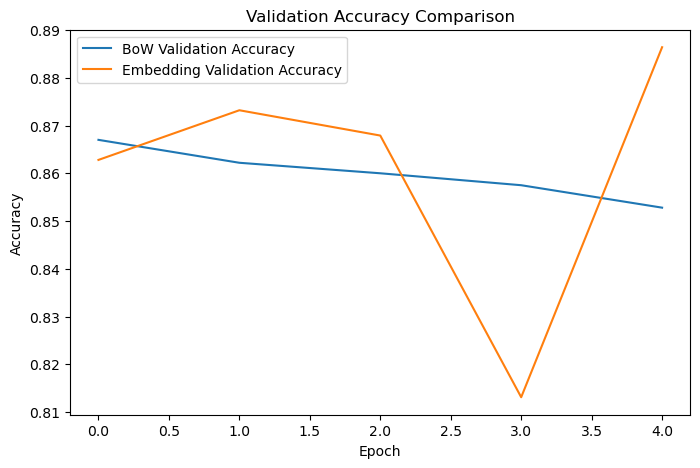

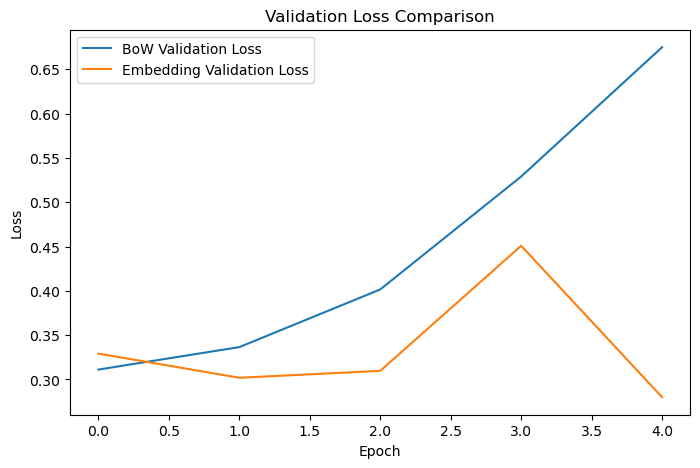

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    bow_history.history["val_accuracy"],
    label="BoW Validation Accuracy"
)

plt.plot(
    embedding_history.history["val_accuracy"],
    label="Embedding Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    bow_history.history["val_loss"],
    label="BoW Validation Loss"
)

plt.plot(
    embedding_history.history["val_loss"],
    label="Embedding Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()